In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

     import the dataset 

In [17]:
df=pd.read_csv("apartments_for_rent_classified_10K.csv",encoding='cp1252',delimiter=';')
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


Data exploration

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [19]:
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [20]:
df.dtypes

id                 int64
category          object
title             object
body              object
amenities         object
bathrooms        float64
bedrooms         float64
currency          object
fee               object
has_photo         object
pets_allowed      object
price              int64
price_display     object
price_type        object
square_feet        int64
address           object
cityname          object
state             object
latitude         float64
longitude        float64
source            object
time               int64
dtype: object

In [21]:
df.describe()

,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


Data preprocessing 

In [22]:
for i, row in enumerate(df['price_type']):
    if row != 'monthly':  # Compare the single row value
        df.loc[i, 'price'] = df.loc[i, 'price'] * 4
df

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5630240092,housing/rent/apartment,Five BR 5407 Abbott Place - Abbott,This unit is located at 5407 Abbott Place - Ab...,NaN,4.0,5.0,USD,No,Thumbnail,...,"$6,000",Monthly,6300,5407 Abbott Place Abbott,Edina,MN,44.9000,-93.3233,RentLingo,1575112975
9996,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
9997,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
9998,5668662559,housing/rent/apartment,One BR in New York NY 10069,"Monthly Rent$4,605 -to $4,790AmenitiesThe Aldy...","Basketball,Cable or Satellite,Doorman,Hot Tub,...",NaN,1.0,USD,No,Thumbnail,...,"$4,790",Monthly,40000,NaN,New York,NY,40.7716,-73.9876,Listanza,1577362186


In [23]:
# Drop unnecessary columns
df = df.drop(['id','category','title','body','currency','fee','has_photo','price_display','price_type','address','cityname','state','time'], axis=1)
df.head()

,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,latitude,longitude,source
0,NaN,NaN,0.0,NaN,3160,101,38.9057,-76.9861,RentLingo
1,NaN,NaN,1.0,NaN,1700,106,37.9680,-87.6621,RentLingo
2,NaN,1.0,0.0,NaN,5560,107,38.8910,-77.0816,RentLingo
3,NaN,1.0,0.0,NaN,3700,116,47.6160,-122.3275,RentLingo
4,NaN,NaN,0.0,NaN,3520,125,38.8738,-77.1055,RentLingo


In [24]:
df['source'].value_counts()

source
RentLingo            6912
RentDigs.com         2764
ListedBuy             179
RealRentals            69
GoSection8             31
Listanza               23
RENTOCULAR             16
rentbits                2
Home Rentals            1
Real Estate Agent       1
RENTCafé                1
tenantcloud             1
Name: count, dtype: int64

In [25]:
df['amenities'].value_counts()

amenities
Parking                                                                                                                                 229
Dishwasher,Refrigerator                                                                                                                 225
Pool                                                                                                                                    171
Dishwasher,Parking,Pool                                                                                                                 149
Dishwasher                                                                                                                              147
                                                                                                                                       ... 
Cable or Satellite,Clubhouse,Dishwasher,Hot Tub,Internet Access,Parking,Patio/Deck,Pool,Refrigerator                                      1
Cable or S

In [26]:
# Create a new column for the number of amenities
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')) if isinstance(x, str) else 0)
df.head()

,amenities,bathrooms,bedrooms,pets_allowed,price,square_feet,latitude,longitude,source,amenities_count
0,NaN,NaN,0.0,NaN,3160,101,38.9057,-76.9861,RentLingo,0
1,NaN,NaN,1.0,NaN,1700,106,37.9680,-87.6621,RentLingo,0
2,NaN,1.0,0.0,NaN,5560,107,38.8910,-77.0816,RentLingo,0
3,NaN,1.0,0.0,NaN,3700,116,47.6160,-122.3275,RentLingo,0
4,NaN,NaN,0.0,NaN,3520,125,38.8738,-77.1055,RentLingo,0


In [27]:
X= df.drop(['amenities'], axis=1)
X.head()

,bathrooms,bedrooms,pets_allowed,price,square_feet,latitude,longitude,source,amenities_count
0,NaN,0.0,NaN,3160,101,38.9057,-76.9861,RentLingo,0
1,NaN,1.0,NaN,1700,106,37.9680,-87.6621,RentLingo,0
2,1.0,0.0,NaN,5560,107,38.8910,-77.0816,RentLingo,0
3,1.0,0.0,NaN,3700,116,47.6160,-122.3275,RentLingo,0
4,NaN,0.0,NaN,3520,125,38.8738,-77.1055,RentLingo,0


Taking care of the missing values

In [28]:
X.isna().sum()

bathrooms            34
bedrooms              7
pets_allowed       4163
price                 0
square_feet           0
latitude             10
longitude            10
source                0
amenities_count       0
dtype: int64

In [29]:
# Drop rows with missing values
X = X.dropna(subset=['latitude','longitude'])
df=df.dropna(subset=['latitude','longitude'])
X.head()

,bathrooms,bedrooms,pets_allowed,price,square_feet,latitude,longitude,source,amenities_count
0,NaN,0.0,NaN,3160,101,38.9057,-76.9861,RentLingo,0
1,NaN,1.0,NaN,1700,106,37.9680,-87.6621,RentLingo,0
2,1.0,0.0,NaN,5560,107,38.8910,-77.0816,RentLingo,0
3,1.0,0.0,NaN,3700,116,47.6160,-122.3275,RentLingo,0
4,NaN,0.0,NaN,3520,125,38.8738,-77.1055,RentLingo,0


In [30]:
X.isna().sum()

bathrooms            34
bedrooms              7
pets_allowed       4156
price                 0
square_feet           0
latitude              0
longitude             0
source                0
amenities_count       0
dtype: int64

In [31]:
from sklearn.impute import SimpleImputer
# Numerical features
num_feature=['bathrooms','bedrooms']
num_imputer=SimpleImputer(strategy='median')
X[num_feature]=num_imputer.fit_transform(X[num_feature])

# Categorical features
cat_feature=['pets_allowed']
cat_imputer=SimpleImputer(strategy='most_frequent')
X[cat_feature]=cat_imputer.fit_transform(X[cat_feature])

Features Scaling

In [32]:
from sklearn.preprocessing import StandardScaler
num_columns=['bathrooms','bedrooms','price','square_feet','latitude','longitude','amenities_count']
scaler = StandardScaler()
X[num_columns] = scaler.fit_transform(X[num_columns])

Encoding the categorical features

In [33]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
cat_columns=['pets_allowed','source']
ct=ColumnTransformer(transformers=[('encoder',
                                    OneHotEncoder(),cat_columns)],
                     remainder='passthrough')

X=ct.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.        , ...,  0.220275  ,
         1.12101843, -0.90865161],
       [ 0.        ,  1.        ,  0.        , ...,  0.04964684,
         0.44356496, -0.90865161],
       [ 0.        ,  1.        ,  0.        , ...,  0.21760012,
         1.11495841, -0.90865161],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.24265664,
         1.10484991, -0.90865161],
       [ 0.        ,  1.        ,  0.        , ...,  0.55980266,
         1.31129046,  2.00779162],
       [ 0.        ,  1.        ,  0.        , ..., -0.67107836,
         0.67573047, -0.32536296]])

Clustering

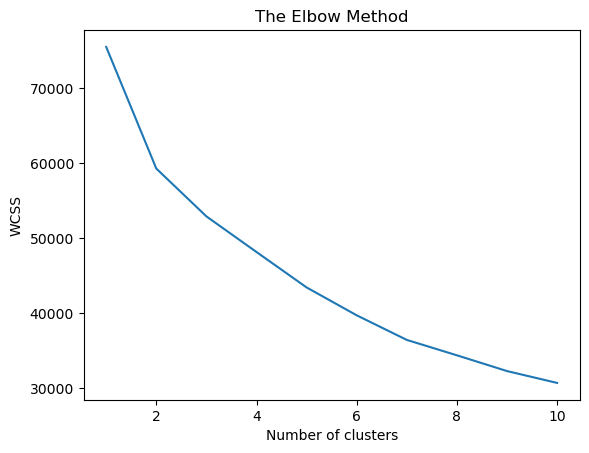

In [34]:
# Find the number of clusters
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++',n_init=10 ,random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

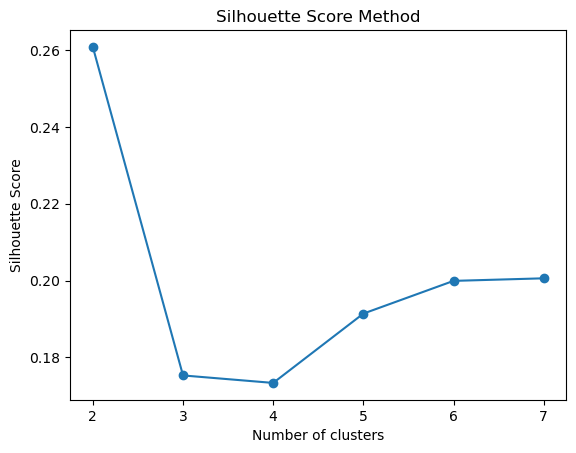

In [35]:
from sklearn.metrics import silhouette_score
range_clusters = range(2, 8)  # Try between 2 and 7 clusters
silhouette_scores = []

for n_clusters in range_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=0)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Plotting the silhouette scores
plt.plot(range_clusters, silhouette_scores, marker='o')
plt.title("Silhouette Score Method")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [36]:
# Select the optimal number of clusters
kmeans = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=0)
ykmeans= kmeans.fit_predict(X)


In [37]:
print(ykmeans)

[0 0 0 ... 1 1 0]


In [38]:
# Add the cluster label to the dataset
df=np.hstack((df,ykmeans.reshape(-1,1)))

In [39]:
df = pd.DataFrame(df,columns=['amenities','bathrooms','bedrooms','pet_allowed','price','square_feet','latitude','longitude','source','amenities_count','clusters'])

In [40]:
import plotly.express as px
fig = px.scatter_mapbox(
    df,
    lat='latitude',
    lon='longitude',
    hover_data=['bathrooms','bedrooms','amenities','price','square_feet','pet_allowed'],
    color='clusters',
    zoom=3,
    height=600
)


fig.update_layout(mapbox_style="carto-positron",
                  )


fig.show()

In [41]:
for i, row in df.iterrows():
    if row['square_feet'] == 40000:
        print(row)

amenities          Basketball,Cable or Satellite,Doorman,Hot Tub,...
bathrooms                                                        NaN
bedrooms                                                         1.0
pet_allowed                                                      NaN
price                                                          19160
square_feet                                                    40000
latitude                                                     40.7716
longitude                                                   -73.9876
source                                                      Listanza
amenities_count                                                   10
clusters                                                           1
Name: 9988, dtype: object


DSBCAN

In [64]:
from sklearn.cluster import DBSCAN
dbscan=DBSCAN(eps=50,min_samples=10)
dbscan.fit(X)

DBSCAN(eps=50, min_samples=10)

In [65]:
len(dbscan.core_sample_indices_)

9989

In [66]:
dbscan.core_sample_indices_[:10]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int64)

In [67]:
np.unique(dbscan.labels_)

array([0], dtype=int64)

In [68]:
labels = dbscan.labels_
# Create a color sequence for the clusters
unique_labels = sorted(set(labels))
n_clusters = len(unique_labels)

# Create DataFrame with cluster labels
df['cluster'] = labels

# Create the map using Plotly
fig = px.scatter_mapbox(df, 
                       lat='latitude', 
                       lon='longitude',
                       color='cluster',
                       color_continuous_scale='viridis',
                       zoom=3,
                       center={'lat': df['latitude'].mean(), 
                              'lon': df['longitude'].mean()},
                       title='DBSCAN Clusters',
                       opacity=0.6,
                       size=[8]*len(df),  # Constant size for all points
                       size_max=8)

# Update the layout to use OpenStreetMap style
fig.update_layout(
    mapbox_style='open-street-map',
    margin={"r":0,"t":30,"l":0,"b":0}
)

# Show the plot
fig.show()